# Phase 1: Exploratory Data Analysis

**Dataset:** Give Me Some Credit (Kaggle)  
**Goal:** Understand the data shape, target imbalance, missing values, distributions, and outliers before any modelling.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_raw

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Load Dataset

In [2]:
df = load_raw()
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Rows: 150,000 | Columns: 11


,serious_dlqin2yrs,revolving_utilization_of_unsecured_lines,age,number_of_time30_59_days_past_due_not_worse,debt_ratio,monthly_income,number_of_open_credit_lines_and_loans,number_of_times90_days_late,number_real_estate_loans_or_lines,number_of_time60_89_days_past_due_not_worse,number_of_dependents
1,1,0.7661,45,2,0.8030,9120.0000,13,0,6,0,2.0000
2,0,0.9572,40,0,0.1219,2600.0000,4,0,0,0,1.0000
3,0,0.6582,38,1,0.0851,3042.0000,2,1,0,0,0.0000
4,0,0.2338,30,0,0.0360,3300.0000,5,0,0,0,0.0000
5,0,0.9072,49,1,0.0249,63588.0000,7,0,1,0,0.0000


In [3]:
df.dtypes

serious_dlqin2yrs                                int64
revolving_utilization_of_unsecured_lines       float64
age                                              int64
number_of_time30_59_days_past_due_not_worse      int64
debt_ratio                                     float64
monthly_income                                 float64
number_of_open_credit_lines_and_loans            int64
number_of_times90_days_late                      int64
number_real_estate_loans_or_lines                int64
number_of_time60_89_days_past_due_not_worse      int64
number_of_dependents                           float64
dtype: object

## 2. Target Distribution

Credit datasets are heavily imbalanced — defaults are rare events. This directly affects which models and metrics we use.

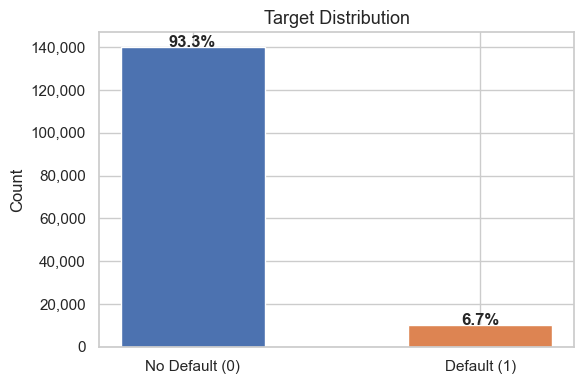

Default rate: 6.68%  →  roughly 1 in 14 borrowers defaults


In [4]:
counts = df['serious_dlqin2yrs'].value_counts().sort_index()
pcts   = df['serious_dlqin2yrs'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No Default (0)', 'Default (1)'], counts.values,
              color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{pct:.1f}%', ha='center', fontweight='bold')
ax.set_title('Target Distribution', fontsize=13)
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

print(f"Default rate: {pcts[1]:.2f}%  →  roughly 1 in {int(100 / pcts[1])} borrowers defaults")

## 3. Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
mv = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
mv[mv['missing_count'] > 0]

,missing_count,missing_pct
monthly_income,29731,19.8200
number_of_dependents,3924,2.6200


## 4. Descriptive Statistics

In [6]:
df.describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
serious_dlqin2yrs,150000.0000,0.0668,0.2497,0.0000,0.0000,0.0000,0.0000,1.0000
revolving_utilization_of_unsecured_lines,150000.0000,6.0484,249.7554,0.0000,0.0299,0.1542,0.5590,50708.0000
age,150000.0000,52.2952,14.7719,0.0000,41.0000,52.0000,63.0000,109.0000
number_of_time30_59_days_past_due_not_worse,150000.0000,0.4210,4.1928,0.0000,0.0000,0.0000,0.0000,98.0000
debt_ratio,150000.0000,353.0051,2037.8185,0.0000,0.1751,0.3665,0.8683,329664.0000
monthly_income,120269.0000,6670.2212,14384.6742,0.0000,3400.0000,5400.0000,8249.0000,3008750.0000
number_of_open_credit_lines_and_loans,150000.0000,8.4528,5.1460,0.0000,5.0000,8.0000,11.0000,58.0000
number_of_times90_days_late,150000.0000,0.2660,4.1693,0.0000,0.0000,0.0000,0.0000,98.0000
number_real_estate_loans_or_lines,150000.0000,1.0182,1.1298,0.0000,0.0000,1.0000,2.0000,54.0000
number_of_time60_89_days_past_due_not_worse,150000.0000,0.2404,4.1552,0.0000,0.0000,0.0000,0.0000,98.0000


## 5. Feature Distributions

Clipped at the 99th percentile so extreme outliers don't compress the histogram.

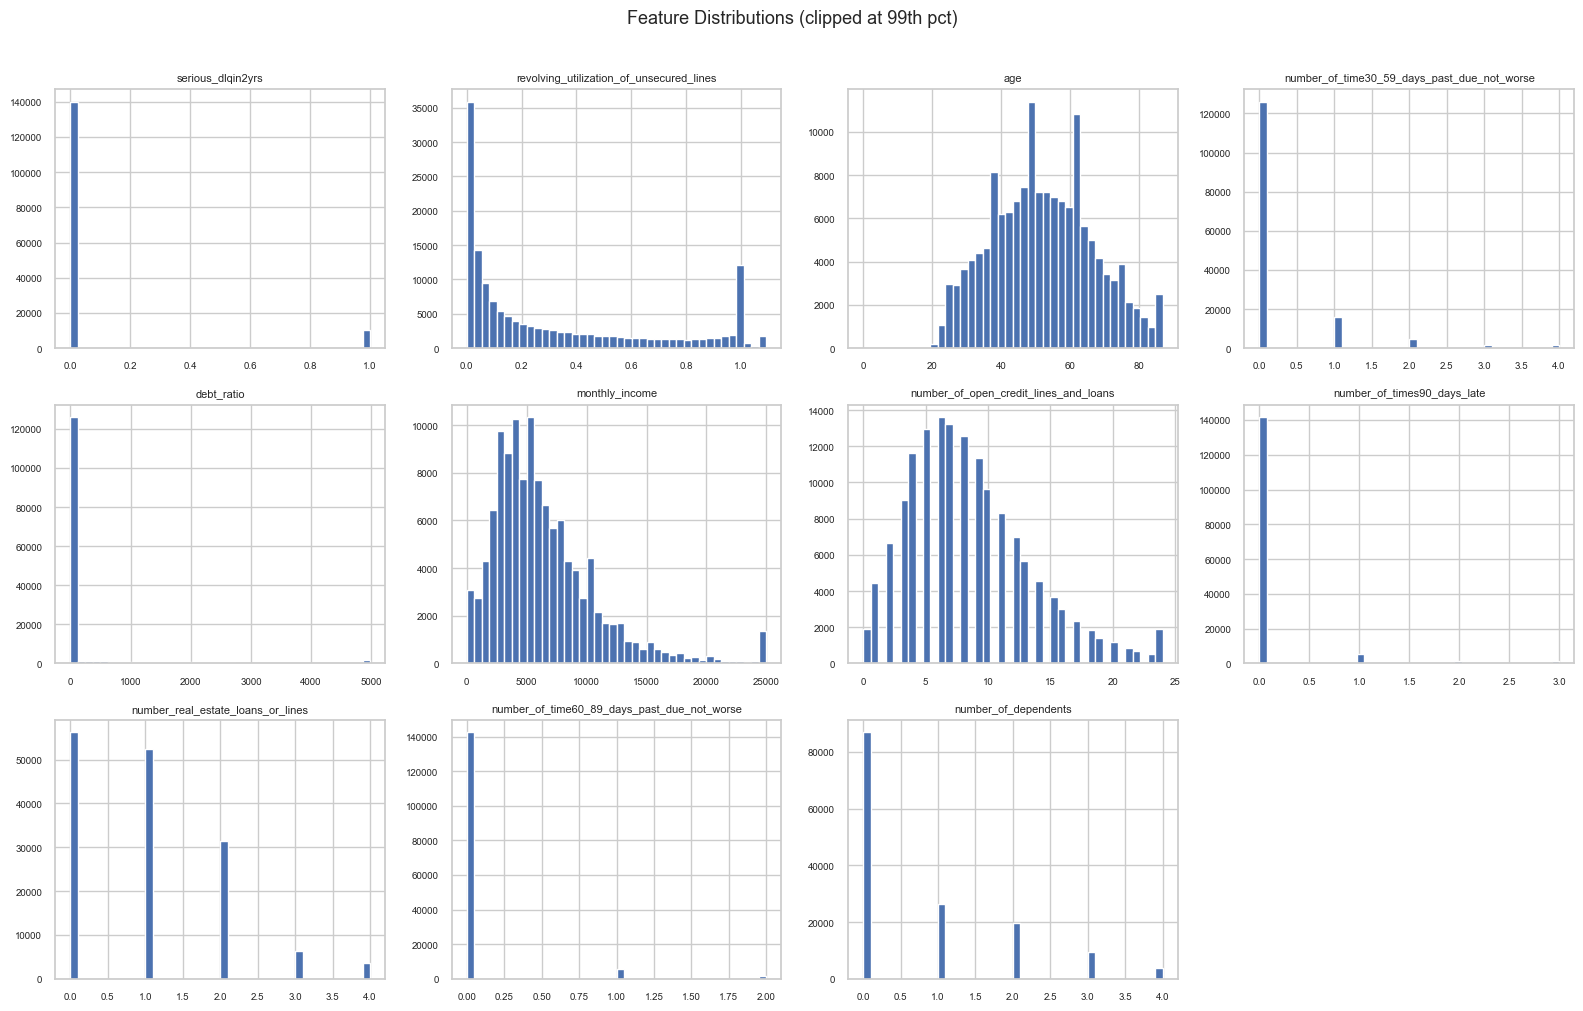

In [7]:
cols = df.columns.tolist()
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    upper = df[col].quantile(0.99)
    df[col].clip(upper=upper).hist(ax=axes[i], bins=40,
                                   color='#4C72B0', edgecolor='white')
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(labelsize=7)

for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions (clipped at 99th pct)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 6. Correlation Matrix

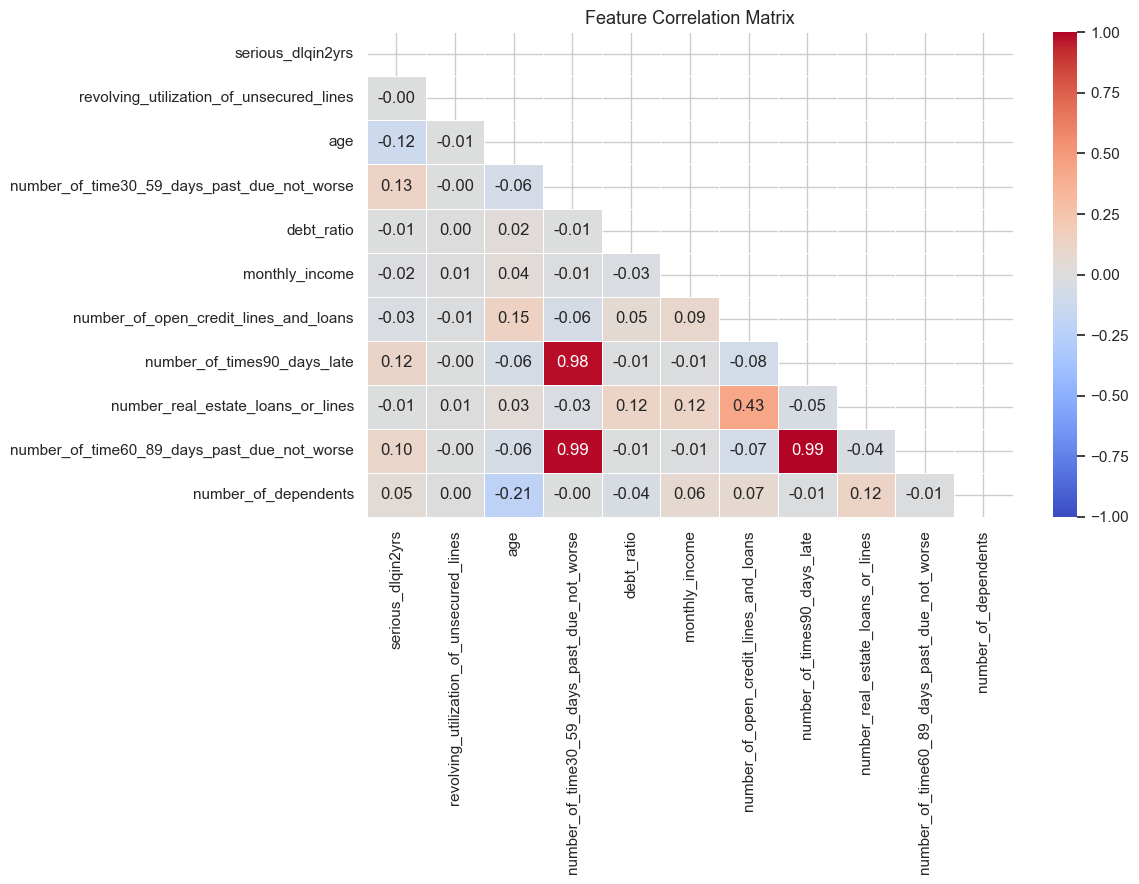

In [8]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Outlier Detection

In [9]:
checks = {
    'utilization > 1 (maxed out)':        (df['revolving_utilization_of_unsecured_lines'] > 1).sum(),
    'utilization > 10 (likely error)':     (df['revolving_utilization_of_unsecured_lines'] > 10).sum(),
    'debt_ratio > 1':                      (df['debt_ratio'] > 1).sum(),
    'age < 18':                            (df['age'] < 18).sum(),
    'monthly_income > 500k':               (df['monthly_income'] > 500_000).sum(),
    'times_90_days_late > 90 (impossible)':(df['number_of_times90_days_late'] > 90).sum(),
}
for label, count in checks.items():
    print(f"  {label:48s}: {count:>6,}")

  utilization > 1 (maxed out)                     :  3,321
  utilization > 10 (likely error)                 :    241
  debt_ratio > 1                                  : 35,137
  age < 18                                        :      1
  monthly_income > 500k                           :     12
  times_90_days_late > 90 (impossible)            :    269


## 8. Default Rate by Feature Decile

Binning each feature into deciles and plotting the default rate per bin reveals monotonic relationships — useful for feature selection and understanding risk drivers.

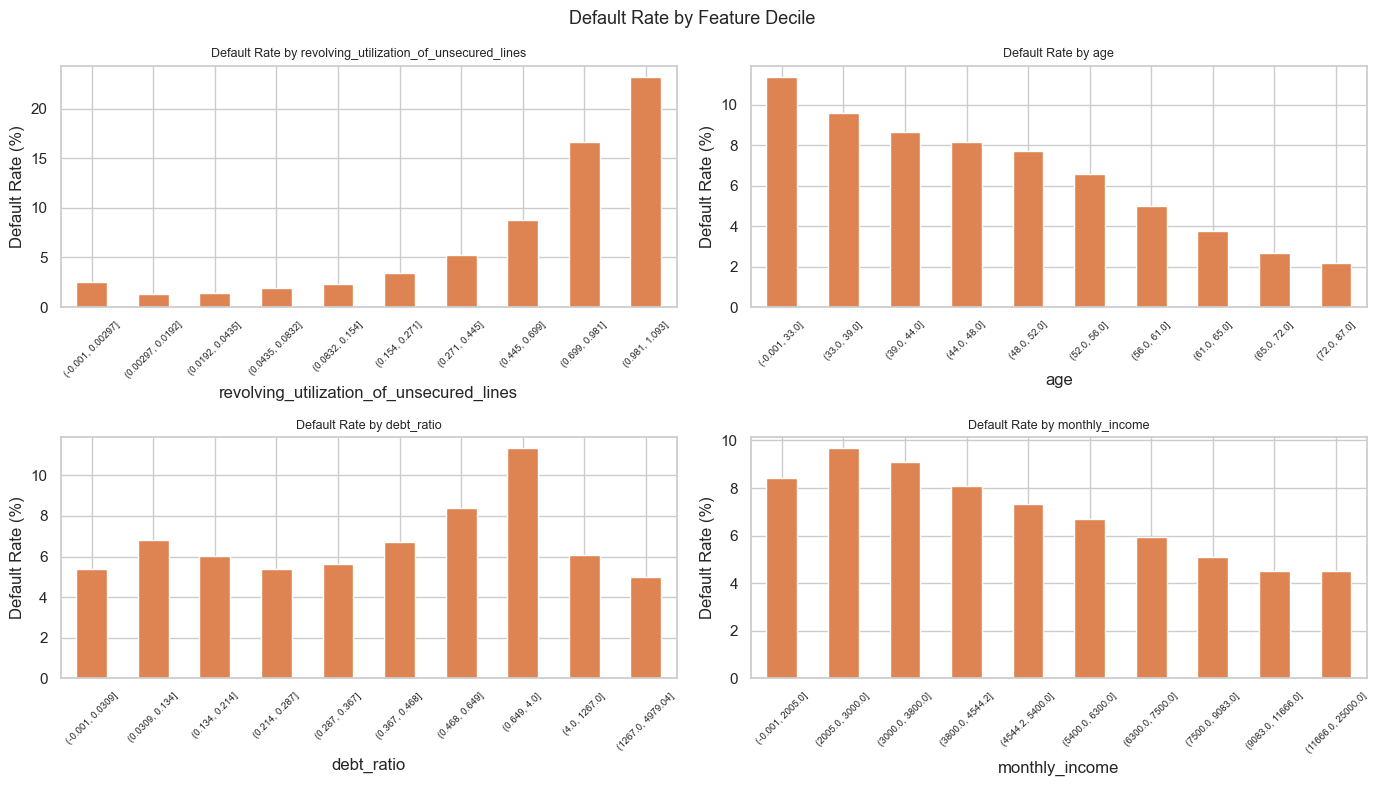

In [10]:
key_features = [
    'revolving_utilization_of_unsecured_lines',
    'age',
    'debt_ratio',
    'monthly_income',
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    clipped = df[col].clip(upper=df[col].quantile(0.99))
    bins = pd.qcut(clipped, q=10, duplicates='drop')
    rate = df.groupby(bins, observed=True)['serious_dlqin2yrs'].mean() * 100
    rate.plot(kind='bar', ax=axes[i], color='#DD8452', edgecolor='white')
    axes[i].set_title(f'Default Rate by {col}', fontsize=9)
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle('Default Rate by Feature Decile', fontsize=13)
plt.tight_layout()
plt.show()

## Key Findings

| Finding | Implication |
|---|---|
| ~7% default rate | Use stratified splits; accuracy is misleading — use AUC/KS/Gini |
| `monthly_income` has ~20% missing | Impute with median (Phase 2) |
| Utilization values > 10 exist | Cap outliers before modelling |
| `number_of_times90_days_late` most correlated with target | Will be top SHAP feature |
| Age negatively correlated with default | Older borrowers are lower risk |